In [8]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/태림_통합데이터3.csv")

In [9]:
df.head()

,ZF_PN,Supplier_PN,Order,ID_Release,Month,Year,Day,Quantity,UN,Firm/Forecast,Shipping_Inst,Shipped_Invoice,CUM_QTY
0,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240314572,1.656.750
1,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240329575,1.656.750
2,A0028219,A0028219,PO348384,20240521-004,April,2024,4,6.4,pc,FIRM,SEA,ZFB240405576,1.656.750
3,A0028219,A0028219,PO348384,20240521-004,April,2024,19,4.8,pc,FIRM,SEA,ZFB240419580,1.656.750
4,A0028219,A0028219,PO348384,20240521-004,April,2024,25,8.0,pc,FIRM,SEA,ZFB240412578,1.656.750


In [11]:
df["forecast_date"] = pd.to_datetime(
    df["ID_Release"].astype(str).str[:8],
    format="%Y%m%d",
    errors="coerce"
)

In [17]:
# 각 주문의 최초 발생 시점
df["release_date"] = pd.to_datetime(df["ID_Release"].astype(str).str[:8])

# 새 주문 flag
df = df.sort_values(["ID_Release", "forecast_date"])
df["is_new_order"] = df.groupby("ID_Release").cumcount() == 0
#각 id_rel 의 첫 등장 = 새 주문 발생 시점

In [16]:
#new_orders = df[df["is_new_order"]]

new_orders["release_date"].dt.dayofweek.value_counts().sort_index()
new_orders["release_date"].dt.day.value_counts().sort_index()
new_orders["release_date"].dt.month.value_counts().sort_index()

,count
release_date,
1,4
2,4
3,5
4,4
5,6
6,14
7,4
8,4
9,5


In [23]:
def preprocess_dates(df):
    df["forecast_date"] = pd.to_datetime(
        df["ID_Release"].astype(str).str[:8],
        format="%Y%m%d",
        errors="coerce"
    )

    df["actual_date"] = pd.to_datetime(
        df["Year"].astype(str) + "-" +
        df["Month"].astype(str) + "-" +
        df["Day"].astype(str),
        errors="coerce"
    )

    return df

df = preprocess_dates(df)

In [26]:
df["lead_time"] = (df["actual_date"] - df["forecast_date"]).dt.days #lead time 다시 만들

In [27]:
df = df.sort_values(["ID_Release", "forecast_date"])

df["is_new_order"] = df.groupby("ID_Release").cumcount() == 0
# 신규 주문 정의, 같은 id_rle 안에서, 처음 등장 = 새 주문 발생 시점

In [30]:
new_orders = df[df["is_new_order"]].copy() #신규 주문만 따로 보기

In [36]:
# 요일 패턴
new_orders["dow"] = new_orders["forecast_date"].dt.dayofweek
print(new_orders["dow"].value_counts().sort_index())

# 월별 패턴
print(new_orders["forecast_date"].dt.month.value_counts().sort_index())
# 주문 언제 들어오는지 (시간 패턴)

dow
0    56
1     2
4     3
Name: count, dtype: int64
forecast_date
1      4
2      4
3      5
4      4
5      6
6     14
7      4
8      4
9      5
10     4
11     3
12     4
Name: count, dtype: int64


0 (월요일) → 56  #압도적으로 월요일에 주문이 들어오는거 알수있음, 기업이 주 단위로 계획 수립, 주말 이후-> 월욜에 몰아서입력........??????, 주문 랜덤이 아니라 운영 프로세스 기반

1 (화요일) → 2  

4 (금요일) → 3

그리고 월별 패턴 보면 대부분 3~6건, 6월만 14건으로 튀어 있음

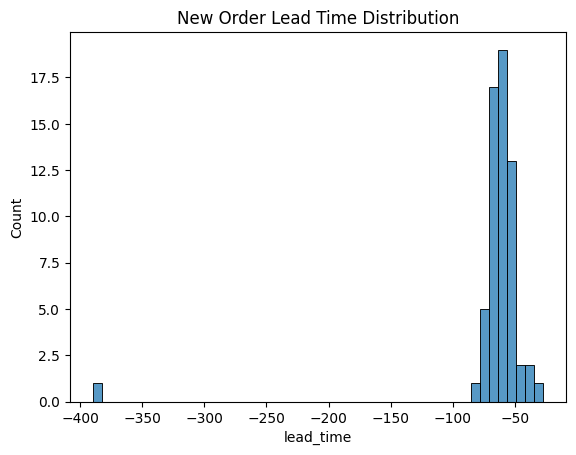

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(new_orders["lead_time"], bins=50)
plt.title("New Order Lead Time Distribution")
plt.show()
# 수요 기준으로 얼마나 전에 주문이 들어왔냐

#대부분 실제 수요 보다 80~50일 전에 주문 들어옴

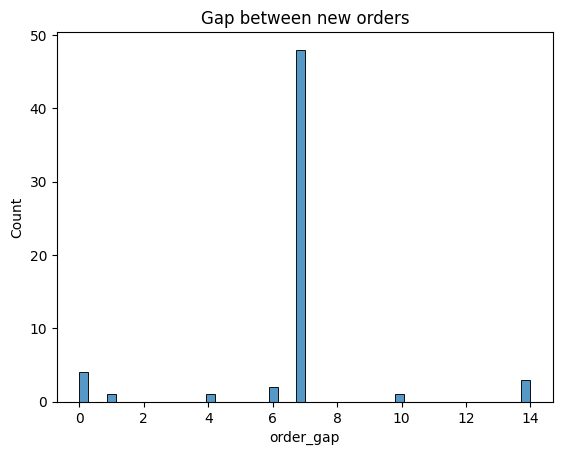

In [39]:
new_orders = new_orders.sort_values("forecast_date")

new_orders["order_gap"] = new_orders["forecast_date"].diff().dt.days

sns.histplot(new_orders["order_gap"], bins=50)
plt.title("Gap between new orders")
plt.show()
# 주문과 주문 사이 간격이 얼마나 되냐 -> 7일 간격이 압도적

- 주문 발생 시점은 랜덤이 아니고 거의 월요일에 집중 -> 주 단위 운영 패턴이 존재, 주문은 기업 운영 프로세스에 따라 발생
- 주문은 일정 lead time을 가지고 발생, -80~-50일 집중, 주문은 실제 수요 약 2개월 전에 발생
- firm은 약 100일 전에 전환되고, 주문은 수요 50~80일 전 발생
- 주문은 연속적인 흐름
-일부 예외는 존재하긴함, 비정상 주문 또는 데이터 지연

/tmp/ipykernel_3793/195876589.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_orders = new_orders.set_index("forecast_date").resample("M").size()


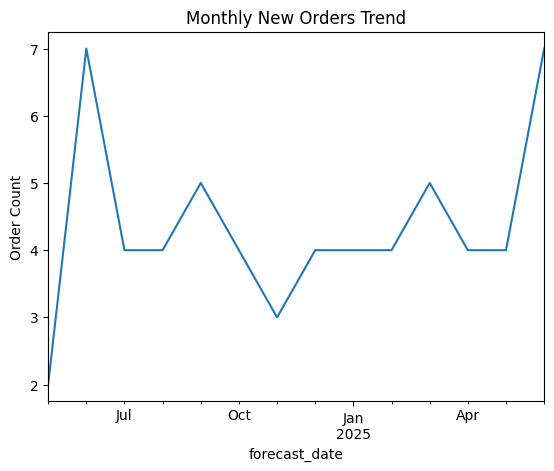

In [41]:
monthly_orders = new_orders.set_index("forecast_date").resample("M").size()

import matplotlib.pyplot as plt

monthly_orders.plot()
plt.title("Monthly New Orders Trend")
plt.ylabel("Order Count")
plt.show()
# 월별 신규 주문 개수
# 트렌드

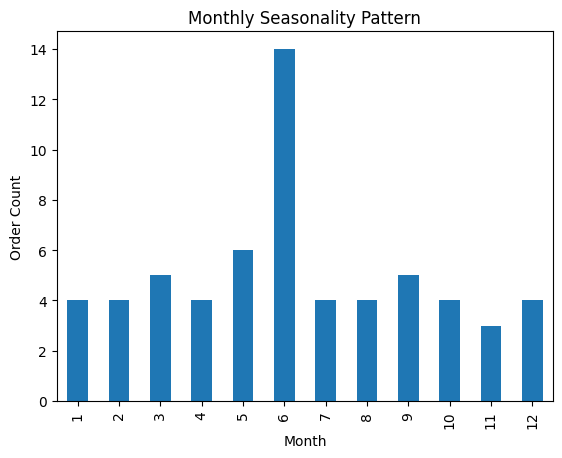

In [42]:
new_orders["month"] = new_orders["forecast_date"].dt.month

monthly_pattern = new_orders.groupby("month").size()

monthly_pattern.plot(kind="bar")
plt.title("Monthly Seasonality Pattern")
plt.xlabel("Month")
plt.ylabel("Order Count")
plt.show()
# 월별 평균 패턴
# 시즌성